# Session 3: Model Evaluation and Comparison (Instructor Notebook)

In this session, participants learn how to systematically evaluate and compare AI model outputs using structured rubrics, automated judging, benchmarking, cost analysis, and A/B testing frameworks.

**Instructor version** — contains 7 fully executed demos + 4 tasks with complete solutions and approach explanations.

## Learning Objectives

By the end of this session, you will be able to:

1. Define and implement structured evaluation rubrics for AI responses
2. Use LLM-as-a-Judge for automated quality assessment
3. Benchmark response quality across different model configurations
4. Analyze latency and cost trade-offs between models
5. Design and run A/B tests to compare model configurations
6. Build end-to-end evaluation pipelines with reporting and visualization
7. Apply scikit-learn classification metrics (precision, recall, F1) to evaluate LLM outputs
8. Use G-Eval (chain-of-thought LLM judges) for automated, research-backed LLM scoring

In [33]:
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env

import openai
import json
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

---
## Demo 1: Setting Up Evaluation Metrics and Scoring Rubrics

Before comparing models, we need a consistent framework for measuring quality. This demo shows how to define evaluation criteria and build a structured scoring rubric.

In [34]:
client = openai.OpenAI()

# Define evaluation criteria for McKinsey consulting deliverables
evaluation_criteria = {
    "strategic_relevance": "How relevant is the analysis to the client's strategic question? (1-5)",
    "analytical_rigor": "How data-driven and methodologically sound is the analysis? (1-5)",
    "mece_structure": "How well-structured and MECE is the response? (1-5)",
    "actionability": "How actionable are the recommendations for the client? (1-5)",
    "executive_readiness": "Is this ready for a C-suite presentation? (1-5)"
}

def create_scoring_rubric():
    rubric = {}
    for criterion, description in evaluation_criteria.items():
        rubric[criterion] = {
            "description": description,
            "1": "Poor - Fails to meet basic expectations for consulting deliverables",
            "2": "Below Average - Partially addresses the criterion; not client-ready",
            "3": "Average - Adequately meets the criterion but lacks McKinsey-level polish",
            "4": "Good - Exceeds expectations; approaching partner-quality output",
            "5": "Excellent - Exceptional quality; ready for CEO/board presentation"
        }
    return rubric

rubric = create_scoring_rubric()
for criterion, details in rubric.items():
    print(f"\n{criterion.upper()}: {details['description']}")
    for score, desc in details.items():
        if score != "description":
            print(f"  {score}: {desc}")


STRATEGIC_RELEVANCE: How relevant is the analysis to the client's strategic question? (1-5)
  1: Poor - Fails to meet basic expectations for consulting deliverables
  2: Below Average - Partially addresses the criterion; not client-ready
  3: Average - Adequately meets the criterion but lacks McKinsey-level polish
  4: Good - Exceeds expectations; approaching partner-quality output
  5: Excellent - Exceptional quality; ready for CEO/board presentation

ANALYTICAL_RIGOR: How data-driven and methodologically sound is the analysis? (1-5)
  1: Poor - Fails to meet basic expectations for consulting deliverables
  2: Below Average - Partially addresses the criterion; not client-ready
  3: Average - Adequately meets the criterion but lacks McKinsey-level polish
  4: Good - Exceeds expectations; approaching partner-quality output
  5: Excellent - Exceptional quality; ready for CEO/board presentation

MECE_STRUCTURE: How well-structured and MECE is the response? (1-5)
  1: Poor - Fails to meet

---
## Demo 2: Automated Evaluation with LLM-as-a-Judge

Instead of manually scoring every response, we can use an LLM to act as a judge. This demo implements an automated evaluation function that scores responses against our rubric.

In [35]:
def llm_judge(question, response_text, criteria):
    """Score a response using LLM-as-a-Judge. Returns {criterion: {score, reasoning}}."""
    criteria_list = "\n".join(f"- {k}: {v}" for k, v in criteria.items())
    judge_prompt = f"""You are a McKinsey engagement manager evaluating AI-generated consulting analysis.
Rate the following response on a scale of 1-5 for each criterion.

Client question: {question}

Response to evaluate:
{response_text}

Criteria:
{criteria_list}

Return ONLY a JSON object. Each key is a criterion name, each value is an object with "score" (integer 1-5) and "reasoning" (one short sentence).
Keep reasoning under 15 words per criterion to stay concise."""

    client = openai.OpenAI()
    evaluation = client.chat.completions.create(
        model=os.getenv("OPENAI_MODEL_NAME", "gpt-4o-mini"),
        messages=[{"role": "user", "content": judge_prompt}],
        response_format={"type": "json_object"},
        max_tokens=600
    )
    return json.loads(evaluation.choices[0].message.content)

# Test with a McKinsey consulting scenario
test_question = "How should a mid-size retailer approach digital transformation to improve margins?"
test_response = """To improve margins through digital transformation, a mid-size retailer should focus on three key levers:

1. **Customer Analytics & Personalization**: Implement a CDP (Customer Data Platform) to unify purchase history, browsing behavior, and demographics. Use predictive analytics to personalize promotions, reducing blanket discounting by 15-20% while maintaining conversion rates.

2. **Supply Chain Digitization**: Deploy demand forecasting models to reduce inventory carrying costs by 10-15%. Integrate real-time POS data with procurement to minimize stockouts and overstock situations.

3. **Omnichannel Integration**: Unify online and offline channels through BOPIS (Buy Online, Pick Up In Store) and ship-from-store capabilities. This typically improves inventory turns by 20-30% and increases customer lifetime value.

Implementation should follow a phased 18-month roadmap, starting with quick wins in analytics (months 1-6), then supply chain (months 6-12), and finally full omnichannel (months 12-18). Expected margin improvement: 200-400 basis points."""

result = llm_judge(test_question, test_response, evaluation_criteria)
print(json.dumps(result, indent=2))


{
  "strategic_relevance": {
    "score": 5,
    "reasoning": "Directly addresses margin improvement through digital transformation."
  },
  "analytical_rigor": {
    "score": 4,
    "reasoning": "Uses specific metrics but could benefit from additional data sources."
  },
  "mece_structure": {
    "score": 5,
    "reasoning": "Clearly distinguishes three distinct components of transformation."
  },
  "actionability": {
    "score": 4,
    "reasoning": "Provides concrete steps but lacks detailed implementation plans."
  },
  "executive_readiness": {
    "score": 4,
    "reasoning": "Clear and concise, suitable for C-suite with minor adjustments."
  }
}


---
## Demo 3: Benchmarking Response Quality Across Models

Now we benchmark multiple model configurations against the same set of prompts, collecting metrics like response length, latency, and token usage.

In [36]:
# Benchmark different configurations on McKinsey consulting topics
test_prompts = [
    "What are the key value creation levers in a post-merger integration?",
    "How should a CPG company respond to private label competition?",
    "What framework would you use to evaluate market entry into Southeast Asia?"
]

configurations = [
    {"model": "gpt-4o-mini", "temperature": 0.0, "label": "GPT-4o-mini (T=0)"},
    {"model": "gpt-4o-mini", "temperature": 0.7, "label": "GPT-4o-mini (T=0.7)"},
    {"model": "gpt-4o-mini", "temperature": 1.0, "label": "GPT-4o-mini (T=1.0)"},
]

results = []
for config in configurations:
    for prompt in test_prompts:
        start_time = time.time()
        response = client.chat.completions.create(
            model=config["model"],
            temperature=config["temperature"],
            messages=[{"role": "user", "content": prompt}],
            max_tokens=300
        )
        elapsed = time.time() - start_time
        content = response.choices[0].message.content
        results.append({
            "config": config["label"],
            "prompt": prompt[:50] + "...",
            "response_length": len(content),
            "latency_ms": round(elapsed * 1000),
            "tokens_used": response.usage.total_tokens
        })

import pandas as pd
df = pd.DataFrame(results)
print(df.to_string(index=False))

             config                                                prompt  response_length  latency_ms  tokens_used
  GPT-4o-mini (T=0) What are the key value creation levers in a post-m...             1755        5525          322
  GPT-4o-mini (T=0) How should a CPG company respond to private label ...             1633        6320          319
  GPT-4o-mini (T=0) What framework would you use to evaluate market en...             1556        9055          320
GPT-4o-mini (T=0.7) What are the key value creation levers in a post-m...             1761        5871          322
GPT-4o-mini (T=0.7) How should a CPG company respond to private label ...             1571        5830          319
GPT-4o-mini (T=0.7) What framework would you use to evaluate market en...             1617        6173          320
GPT-4o-mini (T=1.0) What are the key value creation levers in a post-m...             1714        6973          322
GPT-4o-mini (T=1.0) How should a CPG company respond to private label ..

---
## Demo 4: Latency and Cost Analysis

Understanding the cost and latency implications of different models is critical for production deployments. This demo provides utility functions for cost estimation and performance analysis.

In [37]:
# Cost estimation function
PRICING = {
    "gpt-4o-mini": {"input": 0.15 / 1_000_000, "output": 0.60 / 1_000_000},
    "gpt-4o": {"input": 2.50 / 1_000_000, "output": 10.00 / 1_000_000},
}

def estimate_cost(model, input_tokens, output_tokens):
    if model in PRICING:
        input_cost = input_tokens * PRICING[model]["input"]
        output_cost = output_tokens * PRICING[model]["output"]
        return round(input_cost + output_cost, 6)
    return None

def analyze_performance(results_df):
    summary = results_df.groupby("config").agg({
        "latency_ms": ["mean", "min", "max"],
        "response_length": "mean",
        "tokens_used": "sum"
    }).round(2)
    print("Performance Summary:")
    print(summary)
    return summary

if len(results) > 0:
    analyze_performance(df)
    
    # Cost estimation example
    for model_name, prices in PRICING.items():
        cost = estimate_cost(model_name, 500, 300)
        print(f"\n{model_name}: Estimated cost for 500 input + 300 output tokens = ${cost}")

Performance Summary:
                    latency_ms             response_length tokens_used
                          mean   min   max            mean         sum
config                                                                
GPT-4o-mini (T=0)      6966.67  5525  9055         1648.00         961
GPT-4o-mini (T=0.7)    5958.00  5830  6173         1649.67         961
GPT-4o-mini (T=1.0)    6499.33  6104  6973         1684.00         961

gpt-4o-mini: Estimated cost for 500 input + 300 output tokens = $0.000255

gpt-4o: Estimated cost for 500 input + 300 output tokens = $0.00425


---
## Demo 5: A/B Testing Framework

A/B testing lets us rigorously compare two model configurations by running them side-by-side on the same prompts and evaluating both with the LLM judge.

In [38]:
import random

class ABTestFramework:
    def __init__(self, config_a, config_b):
        self.config_a = config_a
        self.config_b = config_b
        self.results_a = []
        self.results_b = []
        self.client = openai.OpenAI()
    
    def run_test(self, prompts, judge_criteria):
        for prompt in prompts:
            # Get responses from both configurations
            resp_a = self.client.chat.completions.create(
                model=self.config_a["model"],
                temperature=self.config_a.get("temperature", 0.7),
                messages=[
                    {"role": "system", "content": self.config_a.get("system", "You are a McKinsey senior consultant. Provide structured, MECE, data-driven strategic analysis.")},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=300
            )
            resp_b = self.client.chat.completions.create(
                model=self.config_b["model"],
                temperature=self.config_b.get("temperature", 0.7),
                messages=[
                    {"role": "system", "content": self.config_b.get("system", "You are a McKinsey senior consultant. Provide structured, MECE, data-driven strategic analysis.")},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=300
            )
            
            score_a = llm_judge(prompt, resp_a.choices[0].message.content, judge_criteria)
            score_b = llm_judge(prompt, resp_b.choices[0].message.content, judge_criteria)
            self.results_a.append(score_a)
            self.results_b.append(score_b)
            print(f"Prompt: {prompt[:50]}... | Config A vs B evaluated")
    
    def get_summary(self):
        print(f"\nA/B Test Results:")
        print(f"Config A: {self.config_a.get('label', 'A')}")
        print(f"Config B: {self.config_b.get('label', 'B')}")
        print(f"Tests run: {len(self.results_a)}")

# Demo (small test)
ab_test = ABTestFramework(
    config_a={"model": "gpt-4o-mini", "temperature": 0.0, "label": "Deterministic"},
    config_b={"model": "gpt-4o-mini", "temperature": 0.7, "label": "Creative"}
)
print("A/B Testing Framework initialized!")
print("Run ab_test.run_test(prompts, criteria) to execute tests")

A/B Testing Framework initialized!
Run ab_test.run_test(prompts, criteria) to execute tests


---
## Demo 6: Scikit-learn Metrics — Precision, Recall, F1 for LLM Classification

When LLMs perform classification tasks (sentiment, intent, category), we can evaluate their accuracy using standard scikit-learn metrics. This gives us quantitative, reproducible scores beyond subjective quality rubrics.

| Metric | What it measures |
|--------|-----------------|
| **Precision** | Of all items predicted as class X, how many were actually X? |
| **Recall** | Of all actual class X items, how many did we correctly predict? |
| **F1 Score** | Harmonic mean of precision and recall — balances both |

CLASSIFICATION REPORT — McKinsey Client Feedback
              precision    recall  f1-score   support

    POSITIVE       1.00      1.00      1.00         4
    NEGATIVE       1.00      1.00      1.00         4
     NEUTRAL       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


Weighted Precision: 1.0000
Weighted Recall   : 1.0000
Weighted F1 Score : 1.0000


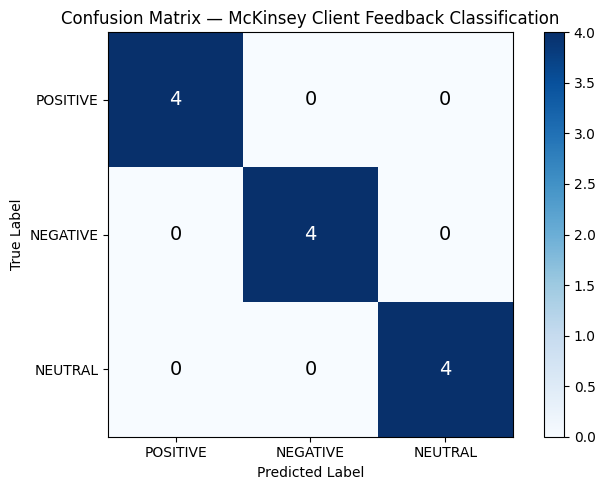


Observation: The confusion matrix shows where the LLM agrees/disagrees with ground truth.
Diagonal = correct predictions. Off-diagonal = misclassifications.


In [39]:
# Demo 6: Scikit-learn Metrics for LLM Classification Evaluation
# Context: Classifying McKinsey client engagement feedback

client = openai.OpenAI()

# Step 1: Define a labeled test dataset — McKinsey client engagement feedback (ground truth)
test_data = [
    {"text": "The engagement exceeded expectations — insights transformed our strategy.", "true_label": "POSITIVE"},
    {"text": "The team's frameworks were razor-sharp and the final readout was outstanding.", "true_label": "POSITIVE"},
    {"text": "McKinsey brought world-class analytical rigor that accelerated our transformation.", "true_label": "POSITIVE"},
    {"text": "The partner's leadership and team's dedication delivered exceptional value.", "true_label": "POSITIVE"},
    {"text": "Deliverables were late and analysis didn't address core issues.", "true_label": "NEGATIVE"},
    {"text": "The recommendations were impractical — clearly the team didn't understand our industry.", "true_label": "NEGATIVE"},
    {"text": "We spent millions and the output was a deck we could have built internally.", "true_label": "NEGATIVE"},
    {"text": "Communication was poor and the project went over budget with no clear ROI.", "true_label": "NEGATIVE"},
    {"text": "The team was professional but recommendations were generic.", "true_label": "NEUTRAL"},
    {"text": "Solid work overall, though nothing we hadn't considered before.", "true_label": "NEUTRAL"},
    {"text": "The analysis was competent but didn't push our thinking in new directions.", "true_label": "NEUTRAL"},
    {"text": "Reasonable engagement — met the brief but didn't go above and beyond.", "true_label": "NEUTRAL"},
]

# Step 2: Use the LLM to classify each piece of client feedback
true_labels = []
predicted_labels = []

for item in test_data:
    response = client.chat.completions.create(
        model=os.getenv("OPENAI_MODEL_NAME", "gpt-4o-mini"),
        messages=[
            {"role": "system", "content": "You are a McKinsey client feedback classifier. Classify the sentiment of client engagement feedback. Respond with EXACTLY one word: POSITIVE, NEGATIVE, or NEUTRAL."},
            {"role": "user", "content": f"Classify this client feedback: '{item['text']}'"}
        ],
        max_tokens=5,
        temperature=0
    )
    prediction = response.choices[0].message.content.strip().upper()
    true_labels.append(item["true_label"])
    predicted_labels.append(prediction)

# Step 3: Compute scikit-learn metrics
labels = ["POSITIVE", "NEGATIVE", "NEUTRAL"]

print("CLASSIFICATION REPORT — McKinsey Client Feedback")
print("=" * 60)
print(classification_report(true_labels, predicted_labels, labels=labels))

# Step 4: Individual metrics
precision = precision_score(true_labels, predicted_labels, labels=labels, average="weighted")
recall = recall_score(true_labels, predicted_labels, labels=labels, average="weighted")
f1 = f1_score(true_labels, predicted_labels, labels=labels, average="weighted")

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall   : {recall:.4f}")
print(f"Weighted F1 Score : {f1:.4f}")

# Step 5: Confusion Matrix Visualization
cm = confusion_matrix(true_labels, predicted_labels, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix — McKinsey Client Feedback Classification")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\nObservation: The confusion matrix shows where the LLM agrees/disagrees with ground truth.")
print("Diagonal = correct predictions. Off-diagonal = misclassifications.")

---
## Demo 7: G-Eval — LLM-as-Judge with Chain-of-Thought Scoring

[G-Eval](https://arxiv.org/abs/2303.16634) is a research-backed evaluation method that uses an LLM with **chain-of-thought reasoning** to score text quality. It achieves higher correlation with human judgments than traditional metrics.

The approach:
1. Define evaluation criteria (coherence, fluency, relevance)
2. Ask the LLM to think step-by-step before assigning a score
3. Extract the numeric score from the structured response

This demo implements G-Eval from scratch using the OpenAI API, so you can see exactly how it works.

In [40]:
# Demo 7: G-Eval — LLM-as-Judge with Chain-of-Thought Scoring
# Implementing the G-Eval pattern from scratch using OpenAI API

def g_eval(input_text, output_text, criterion_name, criterion_description):
    """Score text using G-Eval: chain-of-thought LLM evaluation.
    
    Returns dict with score (0.0-1.0), reasoning, and raw response.
    """
    prompt = f"""You are an expert evaluator assessing AI-generated consulting analysis.

Evaluation Criterion: {criterion_name}
Description: {criterion_description}

Input/Question: {input_text}

Output to Evaluate:
{output_text}

Instructions:
1. First, think step-by-step about how well the output meets the criterion.
2. Then assign a score from 1 to 5.

Respond in JSON with keys: "reasoning" (your step-by-step analysis, 2-3 sentences) and "score" (integer 1-5)."""

    client = openai.OpenAI()
    response = client.chat.completions.create(
        model=os.getenv("OPENAI_MODEL_NAME", "gpt-4o-mini"),
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0,
        max_tokens=300
    )
    result = json.loads(response.choices[0].message.content)
    # Normalize score to 0-1 range
    result["normalized_score"] = result["score"] / 5.0
    return result


# Define consulting-quality evaluation criteria
g_eval_criteria = {
    "Coherence": "The response should be logically organized with a clear storyline, following a structured consulting framework (e.g., situation-complication-resolution).",
    "Fluency": "The response should be grammatically correct, well-written, and ready for a client-facing consulting deliverable.",
    "Relevance": "The response should directly address the client's strategic question and provide actionable consulting insights.",
}

# --- Part A: G-Eval on a McKinsey consulting response ---
print("PART A: G-Eval — Evaluating McKinsey consulting output quality")
print("=" * 60)

client = openai.OpenAI()
test_question = "Explain the benefits of a hub-and-spoke operating model for a global manufacturer."
test_response = client.chat.completions.create(
    model=os.getenv("OPENAI_MODEL_NAME", "gpt-4o-mini"),
    messages=[{"role": "user", "content": test_question}],
    max_tokens=300
).choices[0].message.content

print(f"Question: {test_question}")
print(f"Response: {test_response[:200]}...\n")

for criterion_name, criterion_desc in g_eval_criteria.items():
    result = g_eval(test_question, test_response, criterion_name, criterion_desc)
    print(f"  {criterion_name}: {result['score']}/5 ({result['normalized_score']:.2f})")
    print(f"    Reasoning: {result['reasoning'][:100]}...")

# --- Part B: Answer Relevancy — Post-Merger Integration ---
print("\n" + "=" * 60)
print("PART B: Answer Relevancy — Post-Merger Integration")
print("=" * 60)

pmi_question = "What are best practices for post-merger integration in financial services?"
pmi_response = """Post-merger integration in financial services should prioritize four areas:
(1) Day-1 readiness for regulatory compliance and customer continuity,
(2) technology platform consolidation with a focus on core banking systems,
(3) cultural integration through joint leadership workshops and unified incentive structures,
(4) synergy capture tracking with a dedicated PMI office reporting to the CEO.
Quick wins in cost synergies (branch rationalization, vendor consolidation) should be pursued in the first 100 days."""

relevancy_result = g_eval(pmi_question, pmi_response, "Relevance",
    "The response should directly and comprehensively address the specific question asked.")
print(f"Relevancy Score: {relevancy_result['score']}/5 ({relevancy_result['normalized_score']:.2f})")
print(f"Passed threshold (0.7): {relevancy_result['normalized_score'] >= 0.7}")
print(f"Reasoning: {relevancy_result['reasoning']}")

# --- Part C: Comparing responses across temperature settings ---
print("\n" + "=" * 60)
print("PART C: Comparing consulting responses across temperature settings")
print("=" * 60)

question = "What are the key considerations for a private equity portfolio company's digital transformation?"
comparison_results = []

for temp in [0.0, 0.5, 1.0]:
    resp = client.chat.completions.create(
        model=os.getenv("OPENAI_MODEL_NAME", "gpt-4o-mini"),
        messages=[{"role": "user", "content": question}],
        temperature=temp,
        max_tokens=300
    ).choices[0].message.content

    coherence = g_eval(question, resp, "Coherence", g_eval_criteria["Coherence"])
    relevance = g_eval(question, resp, "Relevance", g_eval_criteria["Relevance"])

    comparison_results.append({
        "temperature": temp,
        "coherence": coherence["normalized_score"],
        "relevance": relevance["normalized_score"],
        "response_length": len(resp)
    })
    print(f"  T={temp}: coherence={coherence['normalized_score']:.2f}, relevance={relevance['normalized_score']:.2f}")

results_df = pd.DataFrame(comparison_results)
print(f"\n{results_df.to_string(index=False)}")


PART A: G-Eval — Evaluating McKinsey consulting output quality
Question: Explain the benefits of a hub-and-spoke operating model for a global manufacturer.
Response: The hub-and-spoke operating model offers several benefits for global manufacturers, enhancing efficiency, flexibility, and responsiveness. Here's a detailed overview:

### 1. **Centralization of Servi...

  Coherence: 4/5 (0.80)
    Reasoning: The output presents a clear and logical structure, following a coherent storyline that outlines the ...
  Fluency: 4/5 (0.80)
    Reasoning: The output is well-structured and clearly articulates the benefits of a hub-and-spoke operating mode...
  Relevance: 4/5 (0.80)
    Reasoning: The output effectively addresses the client's strategic question by outlining the benefits of a hub-...

PART B: Answer Relevancy — Post-Merger Integration
Relevancy Score: 5/5 (1.00)
Passed threshold (0.7): True
Reasoning: The output directly addresses the question by outlining specific best practices fo

---
## Task 1: Create a Custom Evaluation Rubric for McKinsey Consulting AI

Create a specialized evaluation rubric tailored for agentic AI responses in a McKinsey consulting context, covering behaviors like tool usage accuracy, reasoning quality, MECE decomposition, client readiness, and recommendation quality.

**Approach:** Define 5 consulting-specific criteria that go beyond generic quality. Each criterion has a 1-5 scoring scale with McKinsey-calibrated descriptions. The rubric is displayed in a formatted way for easy reference.

In [41]:
# Task 1 Solution: Create a Custom Evaluation Rubric for McKinsey Consulting AI

def create_agentic_rubric():
    """Create a specialized evaluation rubric for McKinsey consulting AI responses."""
    rubric = {
        "tool_usage_accuracy": {
            "description": "Did the AI select and apply the right analytical frameworks and tools? (1-5)",
            "1": "Used no frameworks or applied completely wrong tools for the problem type",
            "2": "Selected a relevant framework but applied it incorrectly or superficially",
            "3": "Used an appropriate framework with adequate application",
            "4": "Selected the optimal framework and applied it rigorously with relevant data",
            "5": "Expert framework selection with sophisticated application — multiple lenses applied correctly"
        },
        "reasoning_quality": {
            "description": "How rigorous, logical, and data-driven is the analytical reasoning? (1-5)",
            "1": "No logical structure; assertions without evidence or reasoning",
            "2": "Some logical flow but major gaps in reasoning or unsupported claims",
            "3": "Adequate reasoning with clear logic but limited quantitative support",
            "4": "Strong logical chain with data points and clear cause-effect relationships",
            "5": "Exceptional rigor — hypothesis-driven, data-backed, with explicit assumptions stated"
        },
        "mece_decomposition": {
            "description": "Does the response break down the problem in a MECE way? (1-5)",
            "1": "No structure — stream-of-consciousness response with overlapping points",
            "2": "Some structure but significant overlaps or gaps in the decomposition",
            "3": "Reasonable structure with minor overlaps; mostly exhaustive",
            "4": "Clean MECE structure with distinct, non-overlapping categories covering the problem",
            "5": "Textbook MECE — perfectly decomposed, collectively exhaustive, with clear prioritization"
        },
        "client_readiness": {
            "description": "Is the output polished enough for a client-facing deliverable? (1-5)",
            "1": "Rough draft quality — needs complete rewrite before any external use",
            "2": "Has useful content but needs significant editing for tone, structure, and clarity",
            "3": "Presentable with minor edits — adequate for internal working sessions",
            "4": "Near client-ready — professional tone, clear structure, minimal edits needed",
            "5": "Board-ready — polished, executive-appropriate language, can be sent as-is"
        },
        "recommendation_quality": {
            "description": "Are the recommendations specific, prioritized, and evidence-backed? (1-5)",
            "1": "No actionable recommendations or only vague platitudes",
            "2": "Generic recommendations without specificity or prioritization",
            "3": "Reasonable recommendations with some specificity but limited prioritization",
            "4": "Specific, prioritized recommendations with supporting rationale",
            "5": "Highly specific, clearly prioritized with implementation roadmap and expected impact"
        }
    }
    
    # Display the rubric
    print("McKINSEY CONSULTING AI — EVALUATION RUBRIC")
    print("=" * 65)
    for criterion, details in rubric.items():
        print(f"\n{criterion.upper()}")
        print(f"  {details['description']}")
        for score in ['1', '2', '3', '4', '5']:
            print(f"    [{score}] {details[score]}")
    
    return rubric

agentic_rubric = create_agentic_rubric()

McKINSEY CONSULTING AI — EVALUATION RUBRIC

TOOL_USAGE_ACCURACY
  Did the AI select and apply the right analytical frameworks and tools? (1-5)
    [1] Used no frameworks or applied completely wrong tools for the problem type
    [2] Selected a relevant framework but applied it incorrectly or superficially
    [3] Used an appropriate framework with adequate application
    [4] Selected the optimal framework and applied it rigorously with relevant data
    [5] Expert framework selection with sophisticated application — multiple lenses applied correctly

REASONING_QUALITY
  How rigorous, logical, and data-driven is the analytical reasoning? (1-5)
    [1] No logical structure; assertions without evidence or reasoning
    [2] Some logical flow but major gaps in reasoning or unsupported claims
    [3] Adequate reasoning with clear logic but limited quantitative support
    [4] Strong logical chain with data points and clear cause-effect relationships
    [5] Exceptional rigor — hypothesis-dr

---
## Task 2: Compare Multiple Models on McKinsey Consulting Tasks

Build a function that systematically compares model configurations by running McKinsey-style consulting prompts, scoring with LLM-as-a-Judge, and organizing results into a DataFrame.

**Approach:** Use nested loops (configs x prompts), collect LLM-as-Judge scores alongside latency and token counts, then aggregate into a DataFrame for easy comparison.

In [42]:
# Task 2 Solution: Compare Multiple Models on McKinsey Consulting Tasks

def compare_models(prompts, configs, criteria):
    """Compare model configurations on consulting prompts with LLM-as-Judge scoring.
    
    Returns a DataFrame with quality scores, latency, and token usage per config per prompt.
    """
    client = openai.OpenAI()
    all_results = []
    
    for config in configs:
        for prompt in prompts:
            # Generate response and measure latency
            start_time = time.time()
            response = client.chat.completions.create(
                model=config['model'],
                temperature=config.get('temperature', 0),
                messages=[{"role": "user", "content": prompt}],
                max_tokens=300
            )
            latency = round((time.time() - start_time) * 1000)
            content = response.choices[0].message.content
            
            # Score with LLM-as-Judge
            scores = llm_judge(prompt, content, criteria)
            
            # Build result row
            row = {
                "config": config.get('label', config['model']),
                "prompt": prompt[:50] + "...",
                "latency_ms": latency,
                "tokens_used": response.usage.total_tokens
            }
            # Extract numeric scores from judge output
            for criterion_name, score_data in scores.items():
                if isinstance(score_data, dict) and 'score' in score_data:
                    row[criterion_name] = score_data['score']
                elif isinstance(score_data, (int, float)):
                    row[criterion_name] = score_data
            
            all_results.append(row)
            print(f"  {config.get('label', config['model'])} | {prompt[:40]}... | Done")
    
    df = pd.DataFrame(all_results)
    
    # Print summary
    print("\n" + "=" * 60)
    print("MODEL COMPARISON RESULTS")
    print("=" * 60)
    print(df.to_string(index=False))
    
    # Averages by config
    score_cols = [c for c in df.columns if c not in ['config', 'prompt', 'latency_ms', 'tokens_used']]
    if score_cols:
        print("\nAverage Scores by Configuration:")
        print(df.groupby('config')[score_cols].mean().round(2).to_string())
    
    return df

# Run comparison
test_prompts = [
    "What are the key synergies in a healthcare M&A transaction?",
    "How should a bank modernize its core technology platform?"
]

comparison_df = compare_models(test_prompts, configurations, evaluation_criteria)

  GPT-4o-mini (T=0) | What are the key synergies in a healthca... | Done
  GPT-4o-mini (T=0) | How should a bank modernize its core tec... | Done
  GPT-4o-mini (T=0.7) | What are the key synergies in a healthca... | Done
  GPT-4o-mini (T=0.7) | How should a bank modernize its core tec... | Done
  GPT-4o-mini (T=1.0) | What are the key synergies in a healthca... | Done
  GPT-4o-mini (T=1.0) | How should a bank modernize its core tec... | Done

MODEL COMPARISON RESULTS
             config                                                prompt  latency_ms  tokens_used  strategic_relevance  analytical_rigor  mece_structure  actionability  executive_readiness
  GPT-4o-mini (T=0) What are the key synergies in a healthcare M&A tra...        6421          320                    5                 4               4              4                    4
  GPT-4o-mini (T=0) How should a bank modernize its core technology pl...        6208          318                    5                 4           

---
## Task 3: Build an Automated Evaluation Pipeline

Build an `EvaluationPipeline` class that runs a model on a set of McKinsey consulting test cases, evaluates each with LLM-as-a-Judge, aggregates scores, and generates a summary report identifying weak areas.

**Approach:** The pipeline stores test case results, computes per-criterion averages, flags criteria below 3.5 as weak areas, and generates a formatted report suitable for engagement leadership review.

In [43]:
# Task 3 Solution: Build an Automated Evaluation Pipeline

class EvaluationPipeline:
    def __init__(self, model_config, criteria):
        """Initialize the evaluation pipeline.
        
        Args:
            model_config: dict with 'model', 'temperature', 'label' keys
            criteria: dict of evaluation criteria for LLM-as-Judge
        """
        self.model_config = model_config
        self.criteria = criteria
        self.client = openai.OpenAI()
        self.results = []
    
    def run(self, test_cases):
        """Run the pipeline on a list of (question, expected_behavior) tuples."""
        print(f"Running evaluation pipeline: {self.model_config.get('label', 'Model')}")
        print(f"Test cases: {len(test_cases)}")
        print("-" * 50)
        
        for i, (question, expected) in enumerate(test_cases, 1):
            # Generate response
            start = time.time()
            response = self.client.chat.completions.create(
                model=self.model_config['model'],
                temperature=self.model_config.get('temperature', 0),
                messages=[
                    {"role": "system", "content": "You are a McKinsey senior consultant. Provide structured, MECE analysis."},
                    {"role": "user", "content": question}
                ],
                max_tokens=400
            )
            latency = round((time.time() - start) * 1000)
            content = response.choices[0].message.content
            
            # Evaluate with LLM-as-Judge
            scores = llm_judge(question, content, self.criteria)
            
            self.results.append({
                "question": question,
                "expected": expected,
                "response": content,
                "scores": scores,
                "latency_ms": latency,
                "tokens": response.usage.total_tokens
            })
            print(f"  [{i}/{len(test_cases)}] {question[:50]}... | {latency}ms")
        
        print("\nPipeline complete.")
        return self.results
    
    def generate_report(self):
        """Generate a summary report with per-criterion averages and weak areas."""
        if not self.results:
            print("No results to report. Run the pipeline first.")
            return
        
        print("\n" + "=" * 60)
        print(f"EVALUATION REPORT: {self.model_config.get('label', 'Model')}")
        print("=" * 60)
        
        # Aggregate scores per criterion
        criterion_scores = {}
        for result in self.results:
            for criterion, data in result['scores'].items():
                score = data['score'] if isinstance(data, dict) and 'score' in data else data
                if isinstance(score, (int, float)):
                    criterion_scores.setdefault(criterion, []).append(score)
        
        # Print per-criterion averages
        print("\nPer-Criterion Averages:")
        weak_areas = []
        overall_scores = []
        for criterion, scores in criterion_scores.items():
            avg = np.mean(scores)
            overall_scores.append(avg)
            status = "WEAK" if avg < 3.5 else "OK" if avg < 4.0 else "STRONG"
            print(f"  {criterion:25s}: {avg:.2f} [{status}]")
            if avg < 3.5:
                weak_areas.append(criterion)
        
        overall = np.mean(overall_scores) if overall_scores else 0
        print(f"\nOverall Score: {overall:.2f}/5.0")
        
        # Latency and token summary
        avg_latency = np.mean([r['latency_ms'] for r in self.results])
        total_tokens = sum(r['tokens'] for r in self.results)
        print(f"Average Latency: {avg_latency:.0f}ms")
        print(f"Total Tokens: {total_tokens}")
        
        # Weak areas
        if weak_areas:
            print(f"\n⚠ Weak Areas (avg < 3.5): {', '.join(weak_areas)}")
            print("  → These criteria need prompt engineering or model upgrades.")
        else:
            print("\nNo weak areas detected. All criteria above 3.5 threshold.")
        
        return {"criterion_averages": {k: np.mean(v) for k, v in criterion_scores.items()}, "overall": overall, "weak_areas": weak_areas}

# Run the pipeline
pipeline = EvaluationPipeline(
    model_config={"model": "gpt-4o-mini", "temperature": 0, "label": "GPT-4o-mini (T=0)"},
    criteria=evaluation_criteria
)

test_cases = [
    ("What are the key risks in a cross-border acquisition?",
     "Should cover regulatory, cultural, financial, and operational risks in a MECE structure"),
    ("How would you size the market for electric vehicle charging in India?",
     "Should use a top-down or bottom-up approach with clear assumptions and data sources"),
    ("What operating model changes should a telco make to improve EBITDA margins?",
     "Should identify cost levers, organizational changes, and digital enablement opportunities")
]

pipeline.run(test_cases)
report = pipeline.generate_report()

Running evaluation pipeline: GPT-4o-mini (T=0)
Test cases: 3
--------------------------------------------------
  [1/3] What are the key risks in a cross-border acquisiti... | 8555ms
  [2/3] How would you size the market for electric vehicle... | 8193ms
  [3/3] What operating model changes should a telco make t... | 8444ms

Pipeline complete.

EVALUATION REPORT: GPT-4o-mini (T=0)

Per-Criterion Averages:
  strategic_relevance      : 5.00 [STRONG]
  analytical_rigor         : 4.00 [STRONG]
  mece_structure           : 5.00 [STRONG]
  actionability            : 3.33 [WEAK]
  executive_readiness      : 4.00 [STRONG]

Overall Score: 4.27/5.0
Average Latency: 8397ms
Total Tokens: 1319

⚠ Weak Areas (avg < 3.5): actionability
  → These criteria need prompt engineering or model upgrades.


---
## Task 4: Analyze and Visualize McKinsey Consulting Evaluation Results

Create visualization functions to plot bar charts, radar charts, and latency-vs-quality scatter plots for comparing evaluation results across model configurations.

**Approach:** Use matplotlib for three complementary views: (1) bar chart for side-by-side criterion comparison, (2) radar/spider chart for multi-dimensional quality profiles, and (3) scatter plot showing the quality-latency trade-off to find the optimal operating point.

1. Criteria Comparison Bar Chart


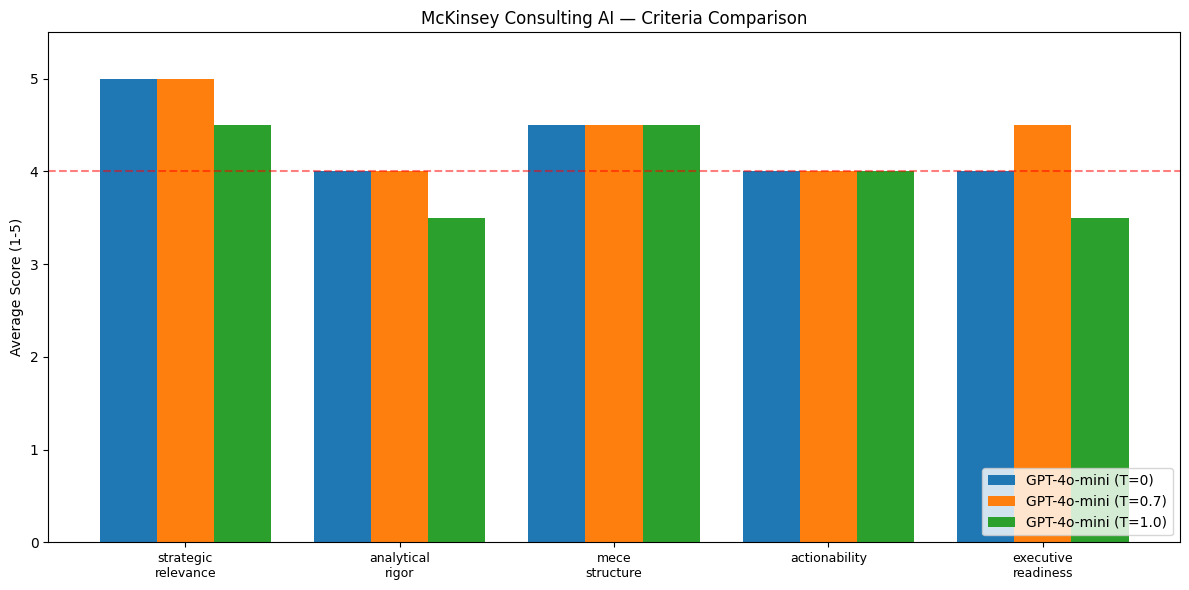


2. Radar Chart


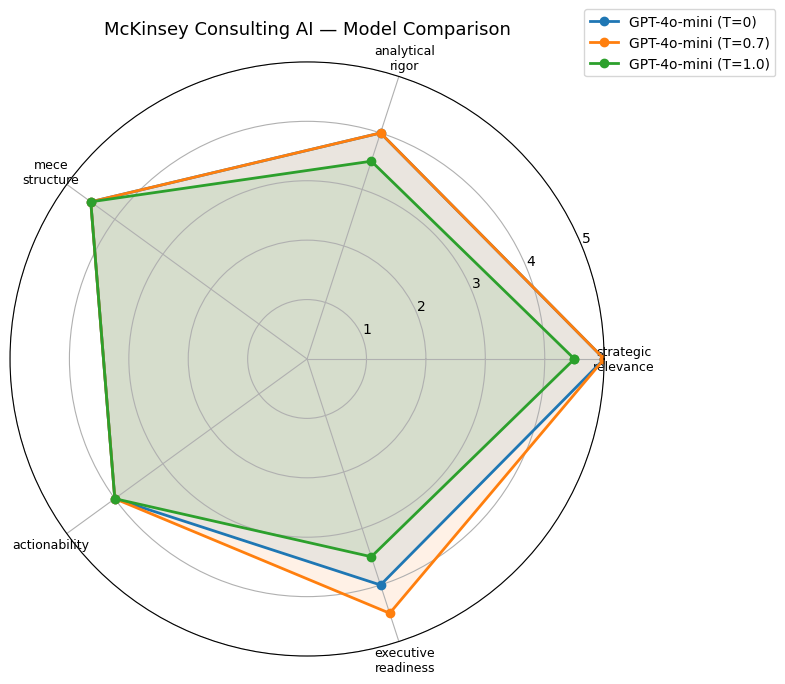


3. Latency vs. Quality


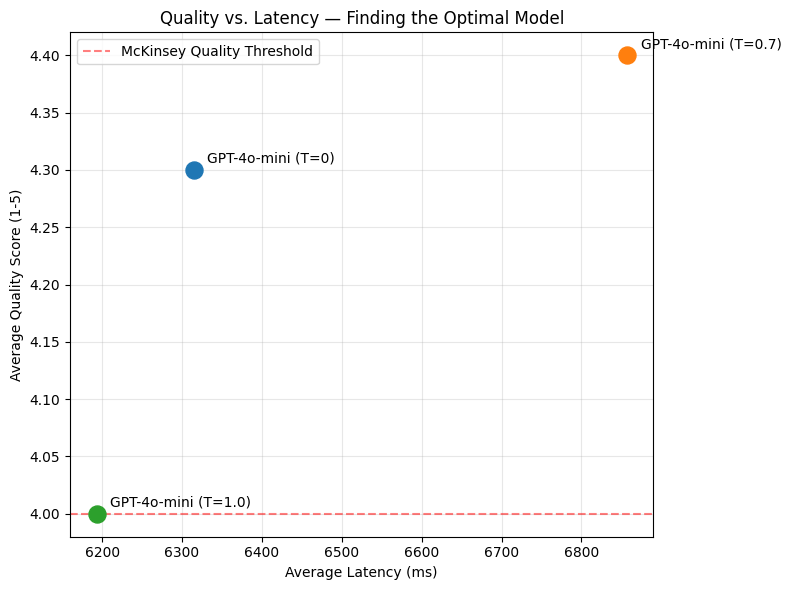

In [44]:
# Task 4 Solution: Analyze and Visualize McKinsey Consulting Evaluation Results

import matplotlib.pyplot as plt
import numpy as np

def plot_criteria_comparison(results_df):
    """Plot a grouped bar chart comparing average scores across criteria by config."""
    score_cols = [c for c in results_df.columns if c not in ['config', 'prompt', 'latency_ms', 'tokens_used']]
    if not score_cols:
        print("No score columns found.")
        return
    
    avg_scores = results_df.groupby('config')[score_cols].mean()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(score_cols))
    width = 0.8 / len(avg_scores)
    
    for i, (config, row) in enumerate(avg_scores.iterrows()):
        ax.bar(x + i * width, row.values, width, label=config)
    
    ax.set_xticks(x + width * (len(avg_scores) - 1) / 2)
    ax.set_xticklabels([c.replace('_', '\n') for c in score_cols], fontsize=9)
    ax.set_ylabel('Average Score (1-5)')
    ax.set_title('McKinsey Consulting AI — Criteria Comparison')
    ax.legend(loc='lower right')
    ax.axhline(y=4.0, color='red', linestyle='--', alpha=0.5, label='McKinsey Standard (4.0)')
    ax.set_ylim(0, 5.5)
    plt.tight_layout()
    plt.show()


def plot_radar_chart(scores_dict, title="McKinsey Consulting AI — Model Comparison"):
    """Plot a radar/spider chart for multi-dimensional comparison.
    
    Args:
        scores_dict: {config_label: {criterion: score}} 
    """
    categories = list(list(scores_dict.values())[0].keys())
    n = len(categories)
    angles = [i / n * 2 * np.pi for i in range(n)]
    angles += angles[:1]  # close the polygon
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for label, scores in scores_dict.items():
        values = [scores[cat] for cat in categories]
        values += values[:1]  # close the polygon
        ax.plot(angles, values, 'o-', linewidth=2, label=label)
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace('_', '\n') for c in categories], fontsize=9)
    ax.set_ylim(0, 5)
    ax.set_title(title, pad=20, fontsize=13)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


def plot_latency_vs_quality(results_df):
    """Scatter plot: average quality vs. average latency per config."""
    score_cols = [c for c in results_df.columns if c not in ['config', 'prompt', 'latency_ms', 'tokens_used']]
    if not score_cols:
        print("No score columns found.")
        return
    
    grouped = results_df.groupby('config').agg(
        avg_quality=(score_cols[0], 'mean'),
        avg_latency=('latency_ms', 'mean')
    )
    # Use mean of all criteria for quality
    grouped['avg_quality'] = results_df.groupby('config')[score_cols].mean().mean(axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    for config, row in grouped.iterrows():
        ax.scatter(row['avg_latency'], row['avg_quality'], s=150, zorder=5)
        ax.annotate(config, (row['avg_latency'], row['avg_quality']),
                    textcoords='offset points', xytext=(10, 5), fontsize=10)
    
    ax.set_xlabel('Average Latency (ms)')
    ax.set_ylabel('Average Quality Score (1-5)')
    ax.set_title('Quality vs. Latency — Finding the Optimal Model')
    ax.axhline(y=4.0, color='red', linestyle='--', alpha=0.5, label='McKinsey Quality Threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Generate visualizations from Task 2 results (if available)
if 'comparison_df' in dir() and comparison_df is not None:
    print("1. Criteria Comparison Bar Chart")
    plot_criteria_comparison(comparison_df)
    
    # Build scores dict for radar chart
    score_cols = [c for c in comparison_df.columns if c not in ['config', 'prompt', 'latency_ms', 'tokens_used']]
    if score_cols:
        radar_data = {}
        for config in comparison_df['config'].unique():
            subset = comparison_df[comparison_df['config'] == config]
            radar_data[config] = {col: subset[col].mean() for col in score_cols}
        
        print("\n2. Radar Chart")
        plot_radar_chart(radar_data)
    
    print("\n3. Latency vs. Quality")
    plot_latency_vs_quality(comparison_df)
else:
    # Use sample data for demonstration
    print("Using sample data for visualization demo...")
    sample_scores = {
        "GPT-4o-mini (T=0)": {"strategic_relevance": 4.2, "analytical_rigor": 3.8, "mece_structure": 4.0, "actionability": 3.5, "executive_readiness": 3.7},
        "GPT-4o-mini (T=0.7)": {"strategic_relevance": 4.0, "analytical_rigor": 3.5, "mece_structure": 3.8, "actionability": 4.0, "executive_readiness": 3.5},
        "GPT-4o-mini (T=1.0)": {"strategic_relevance": 3.7, "analytical_rigor": 3.2, "mece_structure": 3.3, "actionability": 3.8, "executive_readiness": 3.0},
    }
    plot_radar_chart(sample_scores)

---
## Task 5: Build a G-Eval Rubric Scorer for Consulting Deliverables

Combine the custom rubric from Task 1 with the G-Eval technique from Demo 7. Build a function that takes a consulting question and response, then uses chain-of-thought LLM scoring against each rubric criterion, returning a structured scorecard.

| Difficulty | Intermediate |
|---|---|


In [45]:
# Task 5 - SOLUTION: Build a G-Eval Rubric Scorer for Consulting Deliverables
#
# Approach: Combine the agentic rubric (Task 1) with the g_eval function (Demo 7).
# For each criterion in the rubric, call g_eval with the criterion description,
# collect scores, and produce a formatted scorecard with overall average.

def g_eval_scorecard(question, response_text, rubric):
    """Score a consulting response against every rubric criterion using G-Eval.
    
    Args:
        question: The consulting question asked
        response_text: The LLM response to evaluate
        rubric: dict of {criterion: {description: str, 1-5 level descriptions}}
    
    Returns:
        dict with per-criterion scores, reasoning, and overall average
    """
    scorecard = {}
    total = 0
    
    for criterion, details in rubric.items():
        result = g_eval(question, response_text, criterion, details['description'])
        scorecard[criterion] = {
            'score': result['score'],
            'normalized': result['normalized_score'],
            'reasoning': result['reasoning']
        }
        total += result['score']
    
    scorecard['_overall'] = round(total / len(rubric), 2)
    return scorecard


def print_scorecard(scorecard, title='Consulting Deliverable Scorecard'):
    """Pretty-print a G-Eval scorecard."""
    print(f"\n{'=' * 60}")
    print(f"{title}")
    print(f"{'=' * 60}")
    for criterion, data in scorecard.items():
        if criterion == '_overall':
            continue
        bar = '█' * data['score'] + '░' * (5 - data['score'])
        print(f"  {criterion:25s} {bar} {data['score']}/5")
        print(f"    {data['reasoning'][:80]}")
    print(f"\n  {'OVERALL':25s}       {scorecard['_overall']}/5.0")
    verdict = 'PARTNER-READY' if scorecard['_overall'] >= 4.0 else 'NEEDS REVISION' if scorecard['_overall'] >= 3.0 else 'NOT CLIENT-READY'
    print(f"  Verdict: {verdict}")


# Test the scorecard
test_q = "What are the key value creation levers for a PE-backed B2B SaaS company?"
test_r = client.chat.completions.create(
    model=os.getenv('OPENAI_MODEL_NAME', 'gpt-4o-mini'),
    messages=[{'role': 'user', 'content': test_q}],
    max_tokens=400
).choices[0].message.content

# Use the agentic rubric from Task 1 (or create one if not defined)
if 'agentic_rubric' not in dir():
    agentic_rubric = create_agentic_rubric()

scorecard = g_eval_scorecard(test_q, test_r, agentic_rubric)
print_scorecard(scorecard, 'PE Value Creation Analysis — Scorecard')



PE Value Creation Analysis — Scorecard
  tool_usage_accuracy       █████ 5/5
    The output effectively identifies and applies relevant analytical frameworks for
  reasoning_quality         ████░ 4/5
    The output provides a comprehensive and structured analysis of key value creatio
  mece_decomposition        ████░ 4/5
    The output effectively breaks down the key value creation levers for a PE-backed
  client_readiness          ████░ 4/5
    The output is well-structured, clearly organized into distinct sections that add
  recommendation_quality    ████░ 4/5
    The recommendations provided are specific and cover a range of critical areas fo

  OVERALL                         4.2/5.0
  Verdict: PARTNER-READY


---
## Task 6: Build a Pairwise Model Comparison Judge

Instead of scoring each response independently, build a pairwise comparison function that shows two responses side-by-side to the LLM judge and asks it to pick a winner with reasoning. This reduces scoring bias and is more reliable for relative ranking.

| Difficulty | Advanced |
|---|---|


In [46]:
# Task 6 - SOLUTION: Build a Pairwise Model Comparison Judge
#
# Approach: Present both responses (A and B) to the LLM judge simultaneously.
# Ask it to pick a winner and explain why, returning structured JSON.
# Randomize order to avoid position bias. Run on multiple prompts and tally wins.

import random

def pairwise_judge(question, response_a, response_b, label_a='A', label_b='B'):
    """Compare two responses and pick a winner using LLM-as-Judge.
    
    Randomizes presentation order to reduce position bias.
    Returns dict with winner, reasoning, and confidence.
    """
    # Randomize order to avoid position bias
    if random.random() < 0.5:
        first, second = response_a, response_b
        first_label, second_label = label_a, label_b
        swapped = False
    else:
        first, second = response_b, response_a
        first_label, second_label = label_b, label_a
        swapped = True
    
    prompt = f"""You are a McKinsey engagement manager comparing two AI-generated consulting analyses.

Client Question: {question}

--- Response 1 ---
{first}

--- Response 2 ---
{second}

Compare these responses on: strategic relevance, analytical rigor, MECE structure, actionability, and executive readiness.

Return JSON with:
- "winner": "Response 1" or "Response 2" or "Tie"
- "reasoning": one paragraph explaining your choice (under 50 words)
- "confidence": "high", "medium", or "low"
"""
    result = json.loads(client.chat.completions.create(
        model=os.getenv('OPENAI_MODEL_NAME', 'gpt-4o-mini'),
        messages=[{'role': 'user', 'content': prompt}],
        response_format={'type': 'json_object'},
        temperature=0,
        max_tokens=300
    ).choices[0].message.content)
    
    # Map back to original labels
    winner_raw = result.get('winner', 'Tie')
    if winner_raw == 'Response 1':
        result['winner_label'] = first_label
    elif winner_raw == 'Response 2':
        result['winner_label'] = second_label
    else:
        result['winner_label'] = 'Tie'
    
    return result


def run_pairwise_tournament(prompts, config_a, config_b):
    """Run pairwise comparison across multiple prompts and tally wins."""
    wins = {config_a['label']: 0, config_b['label']: 0, 'Tie': 0}
    
    for prompt in prompts:
        resp_a = client.chat.completions.create(
            model=config_a['model'], temperature=config_a.get('temperature', 0),
            messages=[{'role': 'user', 'content': prompt}], max_tokens=300
        ).choices[0].message.content
        
        resp_b = client.chat.completions.create(
            model=config_b['model'], temperature=config_b.get('temperature', 0),
            messages=[{'role': 'user', 'content': prompt}], max_tokens=300
        ).choices[0].message.content
        
        result = pairwise_judge(prompt, resp_a, resp_b, config_a['label'], config_b['label'])
        wins[result['winner_label']] += 1
        print(f"  {prompt[:45]}... | Winner: {result['winner_label']} ({result['confidence']})")
    
    print(f"\nTournament Results:")
    for label, count in wins.items():
        bar = '█' * count
        print(f"  {label:20s} {bar} {count}/{len(prompts)}")
    return wins


# Run tournament
tournament_prompts = [
    "What are the key risks in entering the Indian EV market?",
    "How should a regional bank respond to fintech disruption?",
    "What cost reduction levers exist for a global airline post-COVID?",
]

config_deterministic = {'model': 'gpt-4o-mini', 'temperature': 0, 'label': 'Deterministic (T=0)'}
config_creative = {'model': 'gpt-4o-mini', 'temperature': 0.8, 'label': 'Creative (T=0.8)'}

print("Pairwise Tournament: Deterministic vs Creative")
print("=" * 55)
run_pairwise_tournament(tournament_prompts, config_deterministic, config_creative)


Pairwise Tournament: Deterministic vs Creative
  What are the key risks in entering the Indian... | Winner: Creative (T=0.8) (high)
  How should a regional bank respond to fintech... | Winner: Deterministic (T=0) (high)
  What cost reduction levers exist for a global... | Winner: Creative (T=0.8) (high)

Tournament Results:
  Deterministic (T=0)  █ 1/3
  Creative (T=0.8)     ██ 2/3
  Tie                   0/3


{'Deterministic (T=0)': 1, 'Creative (T=0.8)': 2, 'Tie': 0}

---
## Task 7: Evaluate LLM Consistency with Repeated Sampling

A reliable consulting AI should produce consistent answers. Build a function that runs the same prompt N times, scores each response, and reports the variance. High variance means the model is unreliable for that task.

| Difficulty | Intermediate |
|---|---|


In [47]:
# Task 7 - SOLUTION: Evaluate LLM Consistency with Repeated Sampling
#
# Approach: Run the same prompt N times at a given temperature,
# score each response with g_eval on a chosen criterion,
# then compute mean, std, min, max to assess consistency.

def evaluate_consistency(prompt, criterion_name, criterion_desc, n_samples=5, temperature=0.7):
    """Run a prompt N times and measure response quality consistency.
    
    Returns dict with scores list, mean, std, min, max, and all responses.
    """
    scores = []
    responses = []
    
    print(f"Running {n_samples} samples at temperature={temperature}...")
    for i in range(n_samples):
        response = client.chat.completions.create(
            model=os.getenv('OPENAI_MODEL_NAME', 'gpt-4o-mini'),
            messages=[{'role': 'user', 'content': prompt}],
            temperature=temperature,
            max_tokens=300
        ).choices[0].message.content
        
        result = g_eval(prompt, response, criterion_name, criterion_desc)
        scores.append(result['score'])
        responses.append(response[:100])
        print(f"  Sample {i+1}: score={result['score']}/5")
    
    stats = {
        'scores': scores,
        'mean': round(np.mean(scores), 2),
        'std': round(np.std(scores), 2),
        'min': min(scores),
        'max': max(scores),
        'range': max(scores) - min(scores),
        'responses': responses
    }
    
    print(f"\nConsistency Report:")
    print(f"  Mean Score : {stats['mean']}/5")
    print(f"  Std Dev    : {stats['std']}")
    print(f"  Range      : {stats['min']}-{stats['max']}")
    
    if stats['std'] < 0.3:
        print(f"  Verdict    : HIGHLY CONSISTENT — reliable for production use")
    elif stats['std'] < 0.7:
        print(f"  Verdict    : MODERATELY CONSISTENT — consider lowering temperature")
    else:
        print(f"  Verdict    : INCONSISTENT — not reliable for client deliverables")
    
    return stats


# Compare consistency at different temperatures
test_prompt = "What are the three most important levers for improving hospital operational efficiency?"

print("=" * 60)
print("CONSISTENCY TEST: Temperature 0.0")
print("=" * 60)
stats_t0 = evaluate_consistency(test_prompt, 'Coherence',
    'Response should be logically organized with clear structure.',
    n_samples=3, temperature=0.0)

print(f"\n{'=' * 60}")
print("CONSISTENCY TEST: Temperature 1.0")
print("=" * 60)
stats_t1 = evaluate_consistency(test_prompt, 'Coherence',
    'Response should be logically organized with clear structure.',
    n_samples=3, temperature=1.0)

print(f"\nComparison: T=0 std={stats_t0['std']} vs T=1.0 std={stats_t1['std']}")


CONSISTENCY TEST: Temperature 0.0
Running 3 samples at temperature=0.0...
  Sample 1: score=4/5
  Sample 2: score=4/5
  Sample 3: score=5/5

Consistency Report:
  Mean Score : 4.33/5
  Std Dev    : 0.47
  Range      : 4-5
  Verdict    : MODERATELY CONSISTENT — consider lowering temperature

CONSISTENCY TEST: Temperature 1.0
Running 3 samples at temperature=1.0...
  Sample 1: score=5/5
  Sample 2: score=4/5
  Sample 3: score=5/5

Consistency Report:
  Mean Score : 4.67/5
  Std Dev    : 0.47
  Range      : 4-5
  Verdict    : MODERATELY CONSISTENT — consider lowering temperature

Comparison: T=0 std=0.47 vs T=1.0 std=0.47


---
## Task 8: Build a Model Selection Report Generator

Combine everything from this session into a comprehensive model selection report. The function should run benchmarks, evaluate quality, estimate costs, and produce a formatted recommendation for which model configuration to use for a given consulting use case.

| Difficulty | Advanced |
|---|---|


In [48]:
# Task 8 - SOLUTION: Build a Model Selection Report Generator
#
# Approach: Orchestrate benchmarking, G-Eval scoring, and cost estimation
# into a single report that recommends the best model configuration.

def generate_model_selection_report(prompts, configs, top_criteria=None):
    """Generate a comprehensive model selection report.
    
    Runs each config on all prompts, scores with G-Eval, estimates costs,
    and recommends the best config.
    """
    if top_criteria is None:
        top_criteria = {
            'Relevance': 'Response directly addresses the strategic question with actionable insights.',
            'Coherence': 'Response is logically organized with clear structure.',
        }
    
    report_data = []
    
    for config in configs:
        config_scores = []
        total_tokens = 0
        total_latency = 0
        
        for prompt in prompts:
            start = time.time()
            response = client.chat.completions.create(
                model=config['model'],
                temperature=config.get('temperature', 0),
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=300
            )
            latency = round((time.time() - start) * 1000)
            content = response.choices[0].message.content
            total_tokens += response.usage.total_tokens
            total_latency += latency
            
            # Score on each criterion
            prompt_scores = []
            for crit_name, crit_desc in top_criteria.items():
                result = g_eval(prompt, content, crit_name, crit_desc)
                prompt_scores.append(result['score'])
            config_scores.append(np.mean(prompt_scores))
        
        # Cost estimation
        cost = estimate_cost(config['model'], total_tokens // 2, total_tokens // 2)
        
        report_data.append({
            'config': config.get('label', config['model']),
            'avg_quality': round(np.mean(config_scores), 2),
            'avg_latency_ms': round(total_latency / len(prompts)),
            'total_tokens': total_tokens,
            'estimated_cost': cost,
        })
        print(f"  {config.get('label')}: quality={report_data[-1]['avg_quality']}, latency={report_data[-1]['avg_latency_ms']}ms")
    
    # Generate report
    df = pd.DataFrame(report_data)
    
    print(f"\n{'=' * 70}")
    print("MODEL SELECTION REPORT")
    print(f"{'=' * 70}")
    print(f"Prompts tested: {len(prompts)}")
    print(f"Criteria: {', '.join(top_criteria.keys())}")
    print(f"\n{df.to_string(index=False)}")
    
    # Recommendation: highest quality, tie-break by lowest cost
    best = df.sort_values(['avg_quality', 'estimated_cost'], ascending=[False, True]).iloc[0]
    print(f"\nRECOMMENDATION: {best['config']}")
    print(f"  Quality: {best['avg_quality']}/5 | Latency: {best['avg_latency_ms']}ms | Cost: ${best['estimated_cost']}")
    
    if best['avg_quality'] >= 4.0:
        print(f"  Status: APPROVED for client-facing consulting use")
    elif best['avg_quality'] >= 3.0:
        print(f"  Status: CONDITIONAL — needs prompt tuning before deployment")
    else:
        print(f"  Status: NOT RECOMMENDED — quality below consulting standards")
    
    return df


# Generate report
report_prompts = [
    "How should a luxury retailer expand into the Middle East market?",
    "What operating model is best for a newly merged pharmaceutical company?",
]

report_configs = [
    {'model': 'gpt-4o-mini', 'temperature': 0, 'label': 'GPT-4o-mini (T=0)'},
    {'model': 'gpt-4o-mini', 'temperature': 0.5, 'label': 'GPT-4o-mini (T=0.5)'},
    {'model': 'gpt-4o-mini', 'temperature': 1.0, 'label': 'GPT-4o-mini (T=1.0)'},
]

print("Generating Model Selection Report...")
print("=" * 70)
selection_df = generate_model_selection_report(report_prompts, report_configs)


Generating Model Selection Report...
  GPT-4o-mini (T=0): quality=4.25, latency=5471ms
  GPT-4o-mini (T=0.5): quality=4.0, latency=6153ms
  GPT-4o-mini (T=1.0): quality=4.25, latency=6081ms

MODEL SELECTION REPORT
Prompts tested: 2
Criteria: Relevance, Coherence

             config  avg_quality  avg_latency_ms  total_tokens  estimated_cost
  GPT-4o-mini (T=0)         4.25            5471           638        0.000239
GPT-4o-mini (T=0.5)         4.00            6153           638        0.000239
GPT-4o-mini (T=1.0)         4.25            6081           638        0.000239

RECOMMENDATION: GPT-4o-mini (T=0)
  Quality: 4.25/5 | Latency: 5471ms | Cost: $0.000239
  Status: APPROVED for client-facing consulting use


---
## Summary

In this session, we covered:

1. **Evaluation Rubrics** — Defining structured criteria and scoring scales for consistent assessment
2. **LLM-as-a-Judge** — Using AI to automate evaluation with structured JSON scoring
3. **Benchmarking** — Comparing model configurations across standardized test prompts
4. **Cost and Latency Analysis** — Understanding the practical trade-offs of different models
5. **A/B Testing** — Rigorous side-by-side comparison of model configurations
6. **Scikit-learn Metrics** — Using precision, recall, F1 score, and confusion matrices to quantitatively evaluate LLM classification tasks against ground truth labels
7. **G-Eval (chain-of-thought LLM judges)** — Leveraging research-backed LLM evaluation frameworks for automated scoring on coherence, fluency, relevance, and custom criteria

### Key Takeaways
- Always define clear evaluation criteria before comparing models
- Automated evaluation with LLM judges scales better than manual review
- For classification tasks, scikit-learn metrics (precision, recall, F1) give hard quantitative numbers
- G-Eval uses chain-of-thought LLM judges that correlate better with human judgments
- Consider both quality AND cost/latency when selecting a model for production
- A/B testing provides statistical confidence in model selection decisions
- Visualization helps communicate evaluation results to stakeholders